# Precipitation Prediction Model Training and Inference

This script trains a machine learning model for predicting precipitation using various environmental datasets and then generates precipitation maps for specific dates. The process includes feature engineering, hyperparameter tuning, model evaluation, and inference on a day-by-day basis.  
**Workflow:**
- Preprocess environmental data (e.g., IMERG precipitation, MODIS COT, CER, CWP) from GeoTIFF files.
- Apply feature engineering, such as calculating the COT-CER ratio and squaring the CWP values.
- Train an XGBoost regression model on historical data using a randomized search for optimal hyperparameters.
- Evaluate the model on validation and test sets using metrics like R², RMSE, and MAE.
- Use the trained model to predict daily precipitation for a date range from 2010 to 2023.
- Save the predicted precipitation maps as GeoTIFF files in a dedicated folder.

The final outputs include daily predicted precipitation maps for each date in the specified range, saved in a "predictions" folder.


### Libraries

In [17]:
import os
import numpy as np
import pandas as pd
import rasterio
import joblib
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import uniform, randint
from rasterio.plot import show
import re
from datetime import datetime, timedelta

## <span style="color: teal;">Modeling </span>

### <span style="color: teal;">Data Preparation and Model Training </span>


In [5]:
# Function for feature engineering
def feature_engineering(X):
    X = X.copy()
    X["COT_CER_Ratio"] = X["Value COT"] / (X["Value CER"] + 1e-6)  #
    X["CWP_Squared"] = X["Value CWP"] ** 2
    return X

# FunctionTransformer for feature engineering
feature_engineering_transformer = FunctionTransformer(feature_engineering)

# Load Data
df = pd.read_csv("merged_final_df_5.csv")
df['Value IMERG'] = df['Value IMERG'] / 10  
df["Date"] = pd.to_datetime(df["Date"])  

# Drop rows where target variable (PRECIPITATION) is missing
df = df.dropna(subset=["PRECIPITATION", "Value IMERG", "Value COT", "Value CER", "Value CWP", "Value ASPECT",
                       "Value TPI", "Value TWI", "Band 1", "Band 2", "Band 3", "Band 4", "Value WVC",
                       "Value topoDiversity", "Value landformsGreece"])

# Define Features and Target
features = ["Value IMERG", "Value COT", "Value CER", "Value CWP", "Value ASPECT",
            "Value TPI", "Value TWI", "Band 1", "Value WVC", "Value topoDiversity", "Value landformsGreece"]
X = df[features]
y = np.log1p(df["PRECIPITATION"])  # Log-transform target variable

# Split Data: Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=41)

# Update the pipeline to use the FunctionTransformer
pipeline = make_pipeline(
    feature_engineering_transformer,  # Add feature engineering step
    QuantileTransformer(n_quantiles=100, output_distribution='normal'),
    XGBRegressor(random_state=42, objective='reg:squarederror')
)

# Hyperparameter tuning using RandomizedSearchCV
param_dist = {
    'xgbregressor__n_estimators': randint(100, 300),
    'xgbregressor__max_depth': randint(3, 7),
    'xgbregressor__learning_rate': uniform(0.01, 0.2),
    'xgbregressor__subsample': uniform(0.7, 0.3),
    'xgbregressor__colsample_bytree': uniform(0.7, 0.3)
}

search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, 
    n_iter=20, cv=10, scoring='r2', verbose=1, n_jobs=-1, random_state=42
)
search.fit(X_train, y_train)

# Best model
best_model = search.best_estimator_

# Save the best model
joblib.dump(best_model, "XGBRegressor_model.pkl")



Fitting 10 folds for each of 20 candidates, totalling 200 fits


['XGBRegressor_model.pkl']

### <span style="color: teal;">Model Evaluation </span>



Validation Set Performance:
Mean Absolute Error: 6.9404
Root Mean Squared Error: 13.6806
R² Score: 0.4035

Test Set Performance:
Mean Absolute Error: 6.1921
Root Mean Squared Error: 10.0414
R² Score: 0.3858


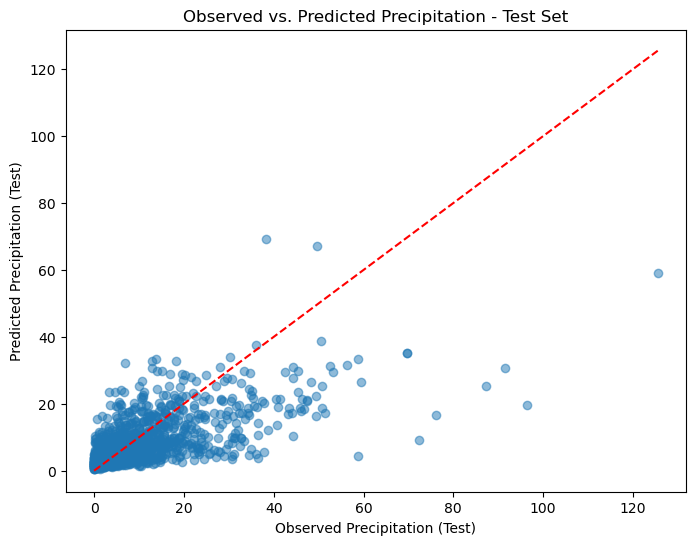

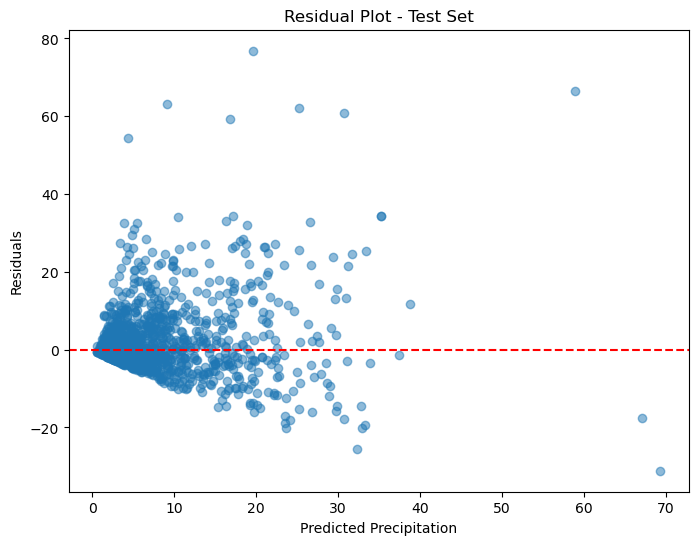

In [4]:
# Evaluate on Validation Set
y_val_pred_log = best_model.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)
y_val_actual = np.expm1(y_val)

val_mae = mean_absolute_error(y_val_actual, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
val_r2 = r2_score(y_val_actual, y_val_pred)

print("\nValidation Set Performance:")
print(f"Mean Absolute Error: {val_mae:.4f}")
print(f"Root Mean Squared Error: {val_rmse:.4f}")
print(f"R² Score: {val_r2:.4f}")

# Evaluate on Test Set
y_test_pred_log = best_model.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)
y_test_actual = np.expm1(y_test)

test_mae = mean_absolute_error(y_test_actual, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_r2 = r2_score(y_test_actual, y_test_pred)

print("\nTest Set Performance:")
print(f"Mean Absolute Error: {test_mae:.4f}")
print(f"Root Mean Squared Error: {test_rmse:.4f}")
print(f"R² Score: {test_r2:.4f}")

# Scatter Plot: Observed vs Predicted Precipitation for Test Set
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_test_pred, alpha=0.5)
plt.xlabel('Observed Precipitation (Test)')
plt.ylabel('Predicted Precipitation (Test)')
plt.title('Observed vs. Predicted Precipitation - Test Set')
plt.plot([0, max(y_test_actual)], [0, max(y_test_actual)], color='red', linestyle='--')  # Diagonal line
plt.show()

# Residual Plot
residuals = y_test_actual - y_test_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Precipitation')
plt.ylabel('Residuals')
plt.title('Residual Plot - Test Set')
plt.show()


## <span style="color: #FFA500;">Inference </span>


### <span style="color:#FFA500;">Loading and Processing GeoTIFF Files for Inference - Check for one date </span>


Shape of Value CER: (706, 896)
Shape of Value COT: (706, 896)
Shape of Value CWP: (706, 896)
Shape of Value IMERG: (706, 896)
Shape of Value WVC: (706, 896)
Shape of Value TWI: (706, 896)
Shape of Value TPI: (706, 896)
Shape of Value ASPECT: (706, 896)
Shape of Value landformsGreece: (706, 896)
Shape of Value topoDiversity: (706, 896)
Shape of Band 1: (706, 896)
Shape of y_pred: (632576,)
Expected shape (original_shape): (706, 896)


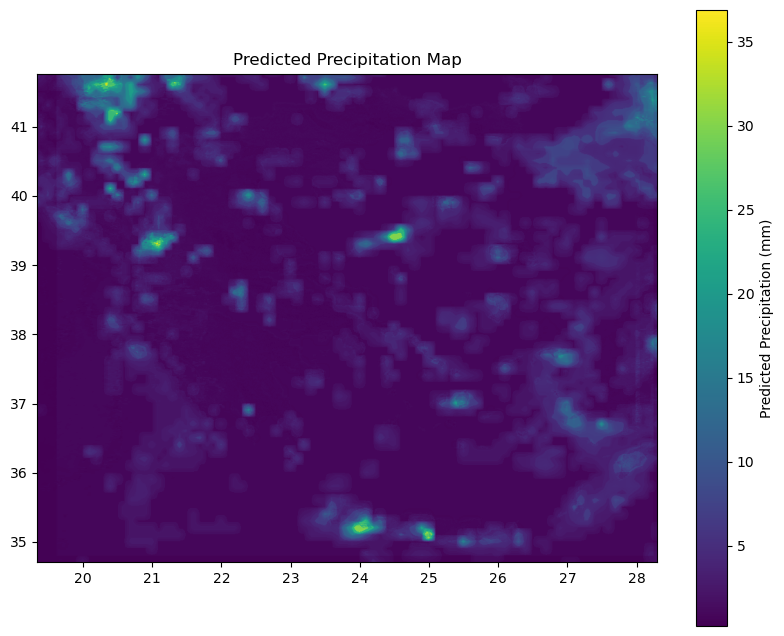

Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predicted_precipitation.tif


In [16]:
# Define base directory
base_dir = os.path.join("/home", "nikkord", "Timos_Asimof", "Assimov", "Scripts_for_uploading/")

# Define paths to GeoTIFF files
paths = {
    "Value CER": os.path.join(base_dir,"resampled_modis_combined/CER", "cer_res_A2020035.tif"),
    "Value COT": os.path.join(base_dir, "resampled_modis_combined/COT","cot_res_A2020035.tif"),
    "Value CWP": os.path.join(base_dir, "resampled_modis_combined/CWP","cwp_res_A2020035.tif"),
    "Value IMERG": os.path.join(base_dir,"Imerg_aggregated_res_1000m", "IMERG_aggregated_20200204_1000m.tif"),
    "Value WVC": os.path.join(base_dir,"resampled_water_vapor","2020","02", "ColumnWV_2020_02_04.tif"),
    "Value TWI": os.path.join(base_dir,"Statics_1000m", "TWI_res.tif"),
    "Value TPI": os.path.join(base_dir,"Statics_1000m", "srtmMtpiGreece_res.tif"),
    "Value ASPECT": os.path.join(base_dir, "Statics_1000m","ASPECT_greece_res.tif"),
    "Value landformsGreece": os.path.join(base_dir, "Statics_1000m","landformsGreece_res.tif"),
    "Value topoDiversity": os.path.join(base_dir,"Statics_1000m", "topoDiversity_res.tif"),
    "Band 1": os.path.join(base_dir,"wind", "20200204_wind.tif")
}

# Load the trained model
model = joblib.load("XGBRegressor_model.pkl")

# Function to read GeoTIFF files and extract pixel values
def read_geotiff(path):
    with rasterio.open(path) as src:
        return src.read(1), src.transform, src.crs

# Read all GeoTIFF files and store their data
data = {}
transform = None
crs = None
original_shape = None  # Store the original 2D shape of the GeoTIFF files

for key, path in paths.items():
    array, transform, crs = read_geotiff(path)
    print(f"Shape of {key}: {array.shape}")

   # Padding !!!!
   # IMERG data may have varying shapes after resampling.
   # Using a zero-filled array during reprojection ensures consistent output dimensions,
   # eliminating the need for padding in this script. Look at def resample_and_pad_raster in 
   # the IMERG Precipitation Data Processing and Resampling.ipynb. If padding needed uncomment the following:

   #  if array.shape != (706, 896):
   #      if key == "Value IMERG":
   #          padded_array = np.zeros((706, 896), dtype=array.dtype)
   #          padded_array[:array.shape[0], :array.shape[1]] = array
   #          array = padded_array
   #      else:
   #          raise ValueError(f"Unexpected shape for {key}: {array.shape}. Expected (706, 896).")

    
    if original_shape is None:
        original_shape = array.shape  # Store the original 2D shape
    data[key] = array.flatten()  # Flatten the array to 1D for DataFrame creation

# Create a DataFrame from the pixel values
df_inference = pd.DataFrame(data)

# Add feature engineering (same as during training)
df_inference["COT_CER_Ratio"] = df_inference["Value COT"] / (df_inference["Value CER"] + 1e-6)
df_inference["CWP_Squared"] = df_inference["Value CWP"] ** 2

# Define the features used for training
features = ["Value IMERG", "Value COT", "Value CER", "Value CWP", "Value ASPECT",
            "Value TPI", "Value TWI", "Band 1", "Value WVC", "Value topoDiversity", "Value landformsGreece",
            "COT_CER_Ratio", "CWP_Squared"]

# Ensure the DataFrame has the same features as used during training
X_inference = df_inference[features]

# Check for infinite or extremely large values
if np.isinf(X_inference).any().any() or (np.abs(X_inference) > 1e30).any().any():
    print("Warning: Infinite or extremely large values detected in X_inference. Handling them...")
    # Replace infinite values with NaN
    X_inference.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Cast to float64 to avoid dtype issues
    X_inference = X_inference.astype(np.float64)
    # Replace extremely large values with a reasonable maximum value
    X_inference.clip(lower=-1e30, upper=1e30, inplace=True)
    # Fill NaN values with the column mean
    X_inference.fillna(X_inference.mean(), inplace=True)

# Predict precipitation using the trained model
y_pred_log = model.predict(X_inference)
y_pred = np.expm1(y_pred_log)  # Reverse the log transformation

# Debug: Check the shape of y_pred
print(f"Shape of y_pred: {y_pred.shape}")
print(f"Expected shape (original_shape): {original_shape}")

# Ensure the number of predictions matches the number of pixels in the original image
if y_pred.size == original_shape[0] * original_shape[1]:
    prediction_array = y_pred.reshape(original_shape)
else:
    # If some rows were dropped, create a mask to map predictions back to the original grid
    print("Warning: Number of predictions does not match the number of pixels in the original image.")
    # Create a mask of valid pixels
    valid_mask = ~np.isnan(X_inference).any(axis=1)
    # Initialize an empty array for the predictions
    prediction_array = np.full(original_shape[0] * original_shape[1], np.nan)
    # Fill the valid pixels with predictions
    prediction_array[valid_mask] = y_pred
    # Reshape to the original 2D shape
    prediction_array = prediction_array.reshape(original_shape)

# Plot the predictions on a map
plt.figure(figsize=(10, 8))

# Use plt.imshow to display the prediction array
im = plt.imshow(prediction_array, cmap='viridis', vmin=np.nanmin(prediction_array), vmax=np.nanmax(prediction_array), extent=rasterio.plot.plotting_extent(prediction_array, transform))

# Add a colorbar
cbar = plt.colorbar(im, label='Predicted Precipitation (mm)')

# Add a title
plt.title('Predicted Precipitation Map')

# Show the plot
plt.show()

# Save the prediction as a GeoTIFF file (optional)
output_path = os.path.join(base_dir, "predicted_precipitation.tif")
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=prediction_array.shape[0],
    width=prediction_array.shape[1],
    count=1,
    dtype=prediction_array.dtype,
    crs=crs,
    transform=transform,
) as dst:
    dst.write(prediction_array, 1)

print(f"Prediction saved to {output_path}")

### <span style="color: #FFA500;">Automating Inference for Multiple Dates</span>


In [23]:
# Define base directory
base_dir = os.path.join("/home", "nikkord", "Timos_Asimof", "Assimov", "Scripts_for_uploading/")

# Create predictions folder inside the base directory
predictions_folder = os.path.join(base_dir, "predictions")
os.makedirs(predictions_folder, exist_ok=True)

# Define paths to static files
static_paths = {
    "Value TWI": os.path.join(base_dir, "Statics_1000m", "TWI_res.tif"),
    "Value TPI": os.path.join(base_dir, "Statics_1000m", "srtmMtpiGreece_res.tif"),
    "Value ASPECT": os.path.join(base_dir, "Statics_1000m", "ASPECT_greece_res.tif"),
    "Value landformsGreece": os.path.join(base_dir, "Statics_1000m", "landformsGreece_res.tif"),
    "Value topoDiversity": os.path.join(base_dir, "Statics_1000m", "topoDiversity_res.tif")
}

# Define paths to folders with sub-folders
dynamic_folders = {
    "Band 1": os.path.join(base_dir, "wind"),
    "Value WVC": os.path.join(base_dir, "resampled_water_vapor"),
    "Value IMERG": os.path.join(base_dir, "Imerg_aggregated_res_1000m"),
    "Value CER": os.path.join(base_dir, "resampled_modis_combined/CER"),
    "Value COT": os.path.join(base_dir, "resampled_modis_combined/COT"),
    "Value CWP": os.path.join(base_dir, "resampled_modis_combined/CWP")
}

# Load the trained model
model = joblib.load("XGBRegressor_model.pkl")

def read_geotiff(path):
    with rasterio.open(path) as src:
        return src.read(1), src.transform, src.crs

def get_dynamic_paths(date):
    year, month, day, date_str = date.strftime("%Y"), date.strftime("%m"), date.strftime("%d"), date.strftime("%Y%m%d")
    return {
        "Band 1": os.path.join(dynamic_folders["Band 1"], f"{date_str}_wind.tif"),
        "Value WVC": os.path.join(dynamic_folders["Value WVC"], year, month, f"ColumnWV_{year}_{month}_{day}.tif"),
        "Value IMERG": os.path.join(dynamic_folders["Value IMERG"], f"IMERG_aggregated_{date_str}_1000m.tif"),
        "Value CER": os.path.join(dynamic_folders["Value CER"], f"cer_res_A{date.strftime('%Y%j')}.tif"),
        "Value COT": os.path.join(dynamic_folders["Value COT"], f"cot_res_A{date.strftime('%Y%j')}.tif"),
        "Value CWP": os.path.join(dynamic_folders["Value CWP"], f"cwp_res_A{date.strftime('%Y%j')}.tif")
    }

def predict_and_save(date):
    dynamic_paths = get_dynamic_paths(date)
    paths = {**static_paths, **dynamic_paths}
    data, transform, crs, original_shape = {}, None, None, None

    for key, path in paths.items():
        try:
            array, transform, crs = read_geotiff(path)
            if array.shape != (706, 896):
                if key == "Value IMERG":
                    padded_array = np.zeros((706, 896), dtype=array.dtype)
                    padded_array[:array.shape[0], :array.shape[1]] = array
                    array = padded_array
                else:
                    raise ValueError(f"Unexpected shape for {key}: {array.shape}. Expected (706, 896).") # in case wrong resampling or padding needed
            if original_shape is None:
                original_shape = array.shape
            data[key] = array.flatten()
        except FileNotFoundError:
            print(f"Missing file: {path}. Skipping...") #cer_res_A2017114 does not exist since there is no any
            #cropped_modis_MOD06_L2.A2017114.1020.061.2017314180719_HEGOUT.tif 
            return
        except Exception as e:
            print(f"Error reading {path}: {e}")
            return

    df_inference = pd.DataFrame(data)
    df_inference["COT_CER_Ratio"] = df_inference["Value COT"] / (df_inference["Value CER"] + 1e-6)
    df_inference["CWP_Squared"] = df_inference["Value CWP"] ** 2

    features = ["Value IMERG", "Value COT", "Value CER", "Value CWP", "Value ASPECT",
                "Value TPI", "Value TWI", "Band 1", "Value WVC", "Value topoDiversity", "Value landformsGreece",
                "COT_CER_Ratio", "CWP_Squared"]

    X_inference = df_inference[features]
    X_inference.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_inference.fillna(X_inference.mean(), inplace=True)

    y_pred_log = model.predict(X_inference)
    y_pred = np.expm1(y_pred_log)

    prediction_array = y_pred.reshape(original_shape)
    output_path = os.path.join(predictions_folder, f"predicted_precipitation_{date.strftime('%Y%m%d')}.tif")

    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=prediction_array.shape[0],
        width=prediction_array.shape[1],
        count=1,
        dtype=prediction_array.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(prediction_array, 1)

    print(f"Prediction saved to {output_path}")

start_date, end_date = datetime(2010, 1, 1), datetime(2023, 12, 31)
while start_date <= end_date:
    print(f"Processing date: {start_date.strftime('%Y-%m-%d')}")
    predict_and_save(start_date)
    start_date += timedelta(days=1)


Processing date: 2010-01-01
Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predictions/predicted_precipitation_20100101.tif
Processing date: 2010-01-02
Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predictions/predicted_precipitation_20100102.tif
Processing date: 2010-01-03
Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predictions/predicted_precipitation_20100103.tif
Processing date: 2010-01-04
Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predictions/predicted_precipitation_20100104.tif
Processing date: 2010-01-05
Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predictions/predicted_precipitation_20100105.tif
Processing date: 2010-01-06
Prediction saved to /home/nikkord/Timos_Asimof/Assimov/Scripts_for_uploading/predictions/predicted_precipitation_20100106.tif
Processing date: 2010-01-07
Prediction saved to /home/nikkord/Timos_Asimof/A